In [ ]:
import torch

path = "/home/x_jiagu/glue-factory/superpoint_lightglue.pth"
state_dict = torch.load(path, map_location='cpu')

if 'state_dict' in state_dict:
    state_dict = state_dict['state_dict']

print(f"{'Parameter Name':<60} | {'Shape':<20}")
print("-" * 85)

for name, param in state_dict.items():
    print(f"{name:<60} | {str(list(param.shape)):<20}")

Parameter Name                                               | Shape               
-------------------------------------------------------------------------------------
posenc.Wr.weight                                             | [32, 2]             
self_attn.0.Wqkv.weight                                      | [768, 256]          
self_attn.0.Wqkv.bias                                        | [768]               
self_attn.0.out_proj.weight                                  | [256, 256]          
self_attn.0.out_proj.bias                                    | [256]               
self_attn.0.ffn.0.weight                                     | [512, 512]          
self_attn.0.ffn.0.bias                                       | [512]               
self_attn.0.ffn.1.weight                                     | [512]               
self_attn.0.ffn.1.bias                                       | [512]               
self_attn.0.ffn.3.weight                                     | [256, 512] 

In [ ]:
from pathlib import Path
root = Path("/proj/vlarsson/datasets/megadepth/Undistorted_SfM")
output_dir = Path("/proj/vlarsson/outputs")
# the scenes exist in MegaDepth
scene_names = sorted([p.name for p in root.iterdir() if p.is_dir()])

In [ ]:
# read gluefactory train_clean list
file_path = "/home/x_jiagu/glue-factory/gluefactory/datasets/megadepth_scene_lists/train_scenes_clean.txt"
with open(file_path,'r')as f:
    gluefactory_lst=[item.strip() for item in f.readlines()]

In [ ]:
# read gluefactory val_clean list
with open("/home/x_jiagu/glue-factory/gluefactory/datasets/megadepth_scene_lists/test_scenes_clean.txt",'r') as f:
    test_lst = [item.strip() for item in f.readlines()]

In [ ]:
# read gluefactory test_clean list
with open("/home/x_jiagu/glue-factory/gluefactory/datasets/megadepth_scene_lists/valid_scenes_clean.txt",'r') as f:
    val_lst = [item.strip() for item in f.readlines()]

In [ ]:
# write full list contains all the scenes we are going to use
full_lst = Path(f"/proj/vlarsson/outputs/splits/full_scenes.txt")
with open(full_lst, 'w') as f:
    for s_n in gluefactory_lst:
        f.write(s_n + "\n")
    for s_n in val_lst:
        f.write(s_n + "\n")
    for s_n in test_lst:
        f.write(s_n + "\n")

In [ ]:
# create our train, validation and test lists
train_path = Path(f"/proj/vlarsson/outputs/splits/train.txt")
val_path = Path(f"/proj/vlarsson/outputs/splits/val.txt")
test_path = Path(f"/proj/vlarsson/outputs/splits/test.txt")

In [65]:
with open(train_path, "w") as f:
    for scene in gluefactory_lst[:94]:
        f.write(scene + "\n")

In [20]:
with open(val_path, "w") as f:
    for scene in val_lst:
        f.write(scene + "\n")

with open(test_path, "w") as f:
    for scene in test_lst[:7]:
        f.write(scene + "\n")

In [2]:
# read to show the current scenes we are using for train, validation and test
from pathlib import Path

output_dir = Path("/proj/vlarsson/outputs")
scene_lst_path = output_dir / "splits"
current_scene_names = [] 
with open(scene_lst_path / "train.txt", "r") as f:
    for name in f.readlines():
        current_scene_names.append(name.strip())
with open(scene_lst_path / "val.txt", "r") as f:
    for name in f.readlines():
        current_scene_names.append(name.strip())
with open(scene_lst_path / "test.txt", "r") as f:
    for name in f.readlines():
        current_scene_names.append(name.strip())

current_scene_names

['0001',
 '0003',
 '0004',
 '0005',
 '0007',
 '0012',
 '0013',
 '0016',
 '0017',
 '0023',
 '0026',
 '0027',
 '0034',
 '0035',
 '0036',
 '0037',
 '0039',
 '0041',
 '0042',
 '0043',
 '0044',
 '0046',
 '0047',
 '0048',
 '0049',
 '0056',
 '0057',
 '0058',
 '0060',
 '0061',
 '0062',
 '0064',
 '0065',
 '0067',
 '0070',
 '0071',
 '0076',
 '0078',
 '0080',
 '0083',
 '0086',
 '0087',
 '0090',
 '0094',
 '0095',
 '0098',
 '0099',
 '0100',
 '0101',
 '0102',
 '0104',
 '0107',
 '0115',
 '0117',
 '0122',
 '0129',
 '0130',
 '0137',
 '0141',
 '0147',
 '0148',
 '0149',
 '0150',
 '0151',
 '0156',
 '0160',
 '0162',
 '0175',
 '0181',
 '0183',
 '0185',
 '0186',
 '0189',
 '0190',
 '0197',
 '0200',
 '0204',
 '0205',
 '0212',
 '0214',
 '0217',
 '0223',
 '0224',
 '0231',
 '0235',
 '0237',
 '0238',
 '0240',
 '0243',
 '0252',
 '0257',
 '0258',
 '0269',
 '0271',
 '0015',
 '0022',
 '0008',
 '0019',
 '0021',
 '0024',
 '0025',
 '0032',
 '0063']

In [ ]:
# a function that counts queries in a log file, save it in case of further use
import re

def stats_query_counts(file_path):
    total_originally = 0
    total_gt_collected = 0
    scene_count = 0

    pattern_total = re.compile(r"(\d+) queries in total originally")
    pattern_gt = re.compile(r"(\d+) queries that have GT collected")

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                match_total = pattern_total.search(line)
                if match_total:
                    total_originally += int(match_total.group(1))
                    scene_count += 1
                
                match_gt = pattern_gt.search(line)
                if match_gt:
                    total_gt_collected += int(match_gt.group(1))

        print("="*30)
        print(f"Total Scenes: {scene_count}")
        print(f"Number of Query In Total Originally: {total_originally}")
        print(f"Number of Query With Non-Zero GT: {total_gt_collected}")
        if total_originally > 0:
            print(f"Ratio: {(total_gt_collected / total_originally)*100:.2f}%")
        print("="*30)

    except FileNotFoundError:
        print(f"Error: Couldn't find {file_path}")

In [ ]:
stats_query_counts(Path("/home/x_jiagu/degree_project/log_file/clean_query.log"))

# Below we can visualize covisible reaults, depth info and GT for a specific query. For dubugging why certain queries have low matchable GT ratio. 

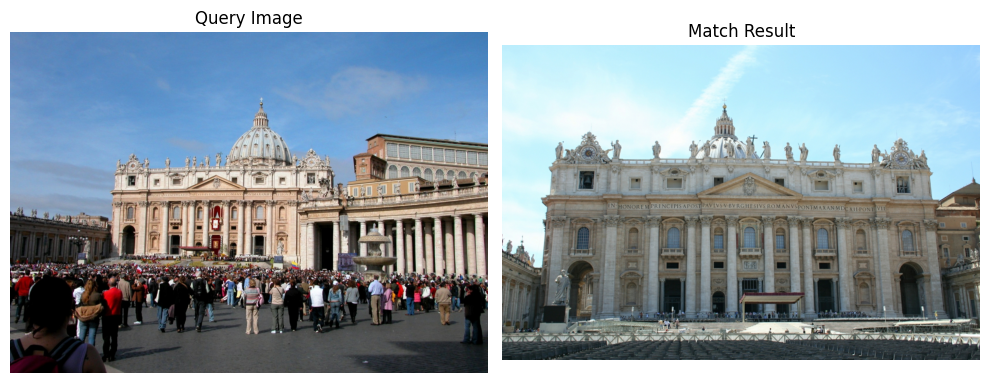

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import pickle

root = Path("/proj/vlarsson/datasets/megadepth/Undistorted_SfM")
scene = "0015"
images_path = root / scene / "images"

test_img_name = '2518736578_578899029c_o.jpg'
ref_img = '170804731_6bf4fbecd4_o.jpg'
img_query = mpimg.imread(images_path / test_img_name)
img_match = mpimg.imread(images_path / ref_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_query)
axes[0].set_title('Query Image')
axes[0].axis('off')

axes[1].imshow(img_match)
axes[1].set_title('Match Result')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
from generate_gt_pairs_by_scene import generate_gt_for_query_list, load_query_cams
import numpy as np

query_list = ["3722247576_38e151fb3e_o.jpg", "1017541041_394e9f81d4_o.jpg", "2518736578_578899029c_o.jpg"]
output_dir = Path("/proj/vlarsson/outputs")
feats_3d_path = output_dir / "midterm_results" / scene / "points3D_feats_cache.h5" # averaged descriptors for all 3D points
feats_2d_path = output_dir / "sfm" / scene / "feats-superpoint-n2048.h5"
depth_path = Path("/proj/vlarsson/datasets/megadepth/depth_undistorted") / scene # depth maps for all queries
covisibility_result_path = output_dir / "midterm_results" / scene / "covisibility_results.pkl" # covisibility results for all queries
query_pose = output_dir / "query_sets" / scene / "query_image_cameras.txt"

query_cams = load_query_cams(query_pose)
with open(covisibility_result_path, "rb") as f:
            covisibility_dict = pickle.load(f)

In [9]:
import h5py

all_query_feats = {}
query_set = set(query_list)
with h5py.File(feats_2d_path, "r") as f_h5:
    all_keys = set(f_h5.keys())
    for img_name in query_set:
        if img_name in all_keys:
            ds = f_h5[img_name]
            all_query_feats[img_name] = {
                "descriptors": ds["descriptors"][:],
                "scores": ds["scores"][:],
                "keypoints": ds["keypoints"][:]
            }

# load 3d descriptors for all the 3d points
points3d_feats = {}
with h5py.File(feats_3d_path, "r") as f_h5:
    all_keys = set(f_h5.keys())
    for id in list(all_keys):
        ds = f_h5[str(id)]
        points3d_feats[str(id)] = {
            "descriptors": ds["descriptors"][:].reshape(1, 256),
            "keypoints": ds["keypoints"][:].reshape(1, 3),
            "scores": ds["scores"][:]
        }

In [14]:
reproj_thresh=3.0
depth_rel_thresh=0.1
gt_default = generate_gt_for_query_list(
        query_list, feats_2d_path, feats_3d_path, query_cams, 
        covisibility_dict, depth_path, reproj_thresh, depth_rel_thresh
        )
matches = gt_default[test_img_name]["matches0"]
ratio = np.sum( matches != -1) / np.shape(matches)[0]
print(f"reprojection error thresh: {reproj_thresh}; depth thresh:{depth_rel_thresh}")
print(f"Overlap ratio: {ratio}")

reprojection error thresh: 3.0; depth thresh:0.1
Overlap ratio: 0.388671875


In [31]:
reproj_thresh=20.0
depth_rel_thresh=0.5
gt_default = generate_gt_for_query_list(
        query_list, feats_2d_path, feats_3d_path, query_cams, 
        covisibility_dict, depth_path, reproj_thresh, depth_rel_thresh
        )
matches = gt_default[test_img_name]["matches0"]
ratio = np.sum( matches != -1) / np.shape(matches)[0]
print(f"reprojection error thresh: {reproj_thresh}; depth thresh:{depth_rel_thresh}")
print(f"Overlap ratio: {ratio}")

reprojection error thresh: 20.0; depth thresh:0.5
Overlap ratio: 0.00048828125


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from utils import qvec2rotmat
from generate_gt_pairs_by_scene import sample_depth_bilinear

def debug_projection_and_depth(
    kpts2d, pts3d, camera, depth_map, 
    reproj_thresh=3.0, depth_rel_thresh=0.1
):
    R = qvec2rotmat(camera["qvec"])
    t = np.array(camera["tvec"]).reshape(3, 1)
    params = camera["intrinsics"]["params"]
    fx, fy, cx, cy = params[:4]
    
    X_cam = R @ pts3d.T + t  # (3, N3D)
    z_proj = X_cam[2]
    valid_z = z_proj > 0
    behind_cam = np.sum(z_proj <= 0)
    print(f"Points behind camera: {behind_cam} / {len(z_proj)}")

    u = fx * (X_cam[0, valid_z] / z_proj[valid_z]) + cx
    v = fy * (X_cam[1, valid_z] / z_proj[valid_z]) + cy
    
    # Depth Histogram
    if depth_map is not None:
        mask_in_img = (u >= 0) & (u < camera["intrinsics"]["width"]) & \
                      (v >= 0) & (v < camera["intrinsics"]["height"]) & (z_proj > 0)
        
        u_in = u[mask_in_img]
        v_in = v[mask_in_img]
        z_in = z_proj[valid_z][mask_in_img]
        
        depth_real = sample_depth_bilinear(depth_map, u_in, v_in).flatten()

        scale = np.median(depth_real[depth_real>0]) / np.median(z_in)
        print(f"Number of non-zero depth values: {np.shape(depth_real[depth_real>0])[0]}")
        print(f"Non-zero depth:{depth_real[depth_real>0]}")
        print(np.median(depth_real[depth_real>0]))
        print(np.median(z_in))
        print(f"scale: {scale}")
        pts3d_valid = pts3d[np.where(valid_z)[0][mask_in_img]]
        # z_aligned = z_in * scale
        # u_in = u_in * scale
        # v_in = v_in * scale
        # X_cam_aligned = (R @ pts3d_valid.T + t ) * scale
        # z_aligned = X_cam_aligned[2]
        # u_in = fx * (X_cam_aligned[0] / z_aligned) + cx
        # v_in = fy * (X_cam_aligned[1] / z_aligned) + cy

        plt.figure(figsize=(10, 5))
        plt.hist(z_in, bins=50, alpha=0.5, label='Projected Z (from 3D points)')
        plt.hist(depth_real[depth_real>0], bins=50, alpha=0.5, label='GT Depth (from Depth Map)')
        plt.title("Depth Distribution Comparison")
        plt.legend()
        plt.show()

        # Projection error Heatmap
        
        rel_error = np.abs(z_in - depth_real) / (depth_real + 1e-6)
        
        plt.figure(figsize=(8, 6))
        sc = plt.scatter(u_in, v_in, c=rel_error, cmap='jet', s=2, vmin=0, vmax=0.5)
        plt.colorbar(sc, label='Relative Depth Error')
        plt.title(f"Depth Relative Error Map")
        plt.gca().invert_yaxis()
        plt.show()

    from scipy.spatial import cKDTree
    projected = np.stack([u_in.flatten(), v_in.flatten()], axis=1)
    tree = cKDTree(kpts2d)
    dists, _ = tree.query(projected)
    reproj_thresh = 5.0
    mask_good = dists <= reproj_thresh
    mask_bad = ~mask_good

    # Visualize 2d vs 3d projection
    plt.figure(figsize=(8, 6))
    plt.scatter(kpts2d[:, 0], kpts2d[:, 1], s=1, c='gray', label='Detected Keypoints', alpha=0.5)
    plt.scatter(u_in, v_in, s=1, c='red', label='Projected 3D Points', alpha=0.3)
    plt.scatter(
        u_in[mask_good], v_in[mask_good], s=3, c='green', label=f'Projected (Error <= {reproj_thresh})', alpha=0.8
        )
    plt.xlim(0, camera["intrinsics"]["width"])
    plt.ylim(camera["intrinsics"]["height"], 0)
    plt.title("2D Keypoints vs Projected 3D Points")
    plt.legend()
    plt.show()

    print(f"Total Reprojection points: {len(u_in)}")
    print(f"Reprojection error < {reproj_thresh} pixels: {np.sum(mask_good)} ({np.sum(mask_good)/len(u_in)*100:.2f}%)")

Points behind camera: 0 / 6230
Number of non-zero depth values: 249
Non-zero depth:[2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         0.30444336
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 1.4515381  1.3138428  2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         2.         2.         2.         2.         2.
 2.         0.97839355 2

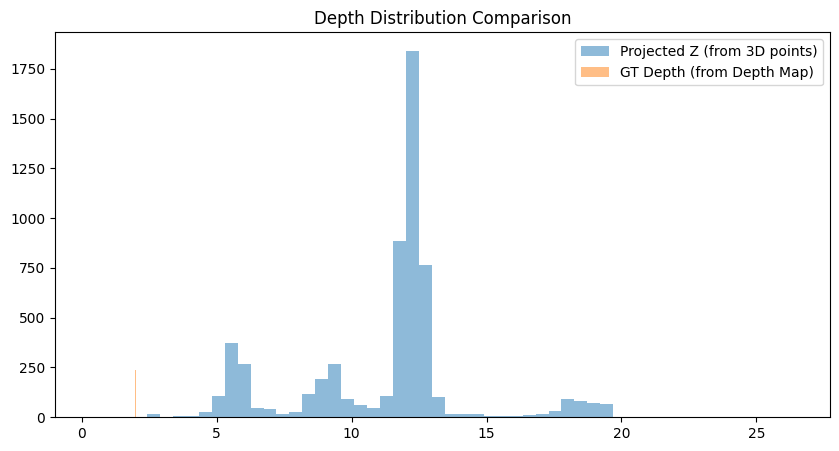

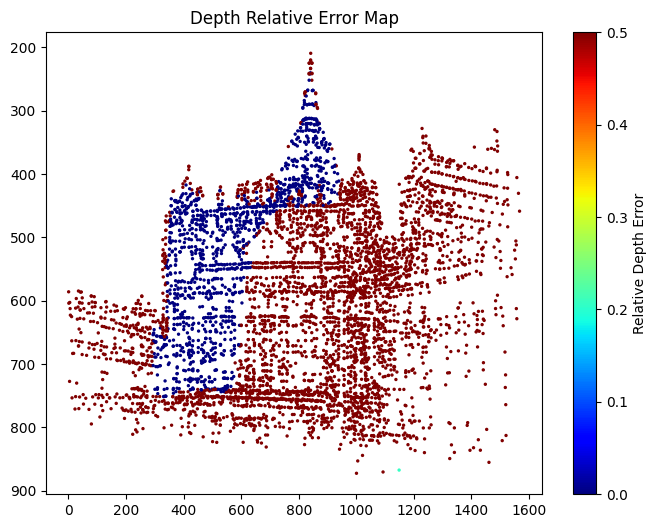

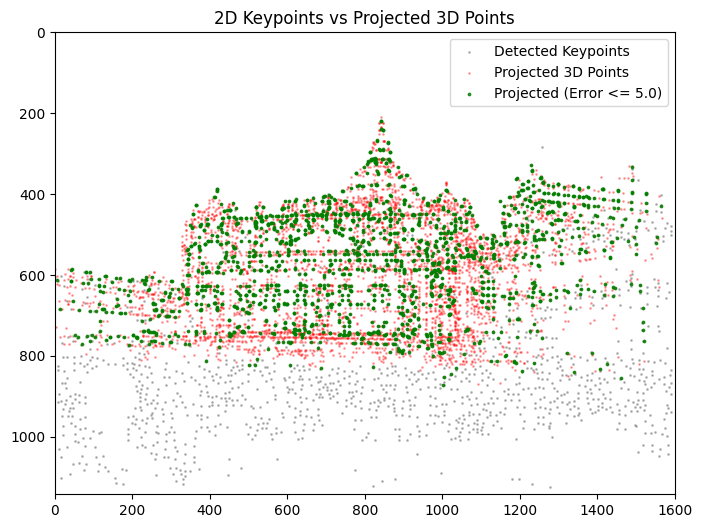

Total Reprojection points: 5848
Reprojection error < 5.0 pixels: 2027 (34.66%)


In [24]:
from generate_gt_pairs_by_scene import load_depth

depth_map = load_depth(depth_path / f"{Path(test_img_name).stem}.h5")
kpts2d = all_query_feats[test_img_name]["keypoints"]

visible_p3d = covisibility_dict[test_img_name]["unique_points"]
valid_p3d = [str(p) for p in visible_p3d if str(p) in points3d_feats]
kpts3d = np.vstack([points3d_feats[p]["keypoints"] for p in valid_p3d])

debug_projection_and_depth(kpts2d, kpts3d, query_cams[test_img_name], depth_map)